## Анализ данных CRM и воронки продаж Soul Tune

**О проекте**

Проект посвящён анализу клиентской базы, продаж и операционной активности музыкальной школы Soul Tune.

Цель анализа — объединить данные из нескольких источников, исследовать ключевые бизнес-показатели и определить основные точки потерь на пути клиента от первого контакта с компанией до покупки и повторного обращения.

**Задачи**

- Проведена загрузка, очистка и проверка качества исходных данных
- Исследована динамика клиентской базы
- Проанализированы записи и посещения занятий
- Изучена загрузка школы и сезонность
- Рассчитаны показатели продаж и повторных покупок
- Проанализированы маркетинговые данные Яндекс.Бизнес
- Сформирована агрегированная воронка взаимодействия с клиентами
- Подготовлены итоговые таблицы для визуализации в Tableau

**Данные**

В анализе используются несколько групп данных:

- CRM — информация о клиентах
- Абонементы и записи в группы
- Занятия
- Платежи
- Статистика посещений
- Данные Яндекс.Бизнес: реклама, сайт, профиль компании и действия пользователей
- Данные по входящим звонкам

**Ограничения данных**

В доступных источниках отсутствует единый идентификатор, позволяющий связать маркетинговый контакт, заявку, клиента, платёж и конкретное занятие в единую последовательность событий.

Поэтому часть воронки строится на агрегированных показателях разных источников и не является классической event funnel. Полученные значения используются для оценки общей структуры взаимодействия с компанией, а не для отслеживания индивидуального пути каждого клиента.

**Результат**

По итогам анализа сформирован набор ключевых бизнес-метрик и подготовлены агрегированные данные для интерактивного дашборда в Tableau.

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import warnings

warnings.filterwarnings(
    "ignore",
    message="Workbook contains no default style"
)

## 2ГИС

### Загрузка и предобработка данных

In [2]:
# заррузка данных из личного кабинета 2ГИС (период 01.01.2025 – 31.01.2026)
gis = pd.read_excel(
    "./data/soultune/2GIS.xlsx",
    skiprows=4,      # пропустить первые 4 строки
    usecols="B:D"    # взять только нужные столбцы
)

In [3]:
gis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Дата              396 non-null    object
 1   Показы            396 non-null    int64 
 2   Позиция в выдаче  396 non-null    object
dtypes: int64(1), object(2)
memory usage: 9.4+ KB


In [4]:
gis['Позиция в выдаче'] = pd.to_numeric(
    gis['Позиция в выдаче'],
    errors='coerce'
)

gis['Дата'] = pd.to_datetime(gis['Дата'], dayfirst=True)

In [5]:
gis['Затраты'] = 0.0
gis.loc[gis['Дата'] == '2025-03-27', 'Затраты'] = 53003.25 # загружаем расход в рамках рассматриваемого периода

gis[gis['Затраты'] > 0]

,Дата,Показы,Позиция в выдаче,Затраты
85,2025-03-27,251,4.0,53003.25


In [6]:
gis.head(10)

,Дата,Показы,Позиция в выдаче,Затраты
0,2025-01-01,73,5.0,0.0
1,2025-01-02,75,5.0,0.0
2,2025-01-03,101,5.0,0.0
3,2025-01-04,88,5.0,0.0
4,2025-01-05,104,5.0,0.0
5,2025-01-06,126,5.0,0.0
6,2025-01-07,91,5.0,0.0
7,2025-01-08,105,5.0,0.0
8,2025-01-09,170,5.0,0.0
9,2025-01-10,210,5.0,0.0


### Исследовательский анализ данных

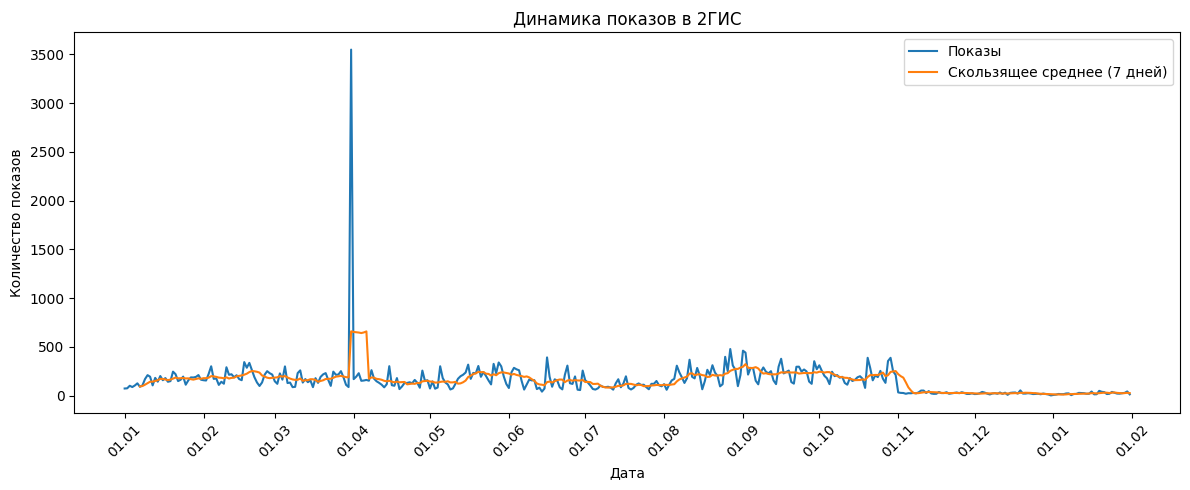

In [7]:
# динамика показов

gis['MA_7'] = gis['Показы'].rolling(7).mean()

plt.figure(figsize=(12,5))
plt.plot(gis['Дата'], gis['Показы'], label='Показы')
plt.plot(gis['Дата'], gis['MA_7'], label='Скользящее среднее (7 дней)')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.xticks(rotation=45)
plt.ylabel('Количество показов')
plt.xlabel('Дата')
plt.title('Динамика показов в 2ГИС')
plt.legend()
plt.tight_layout()
plt.show()

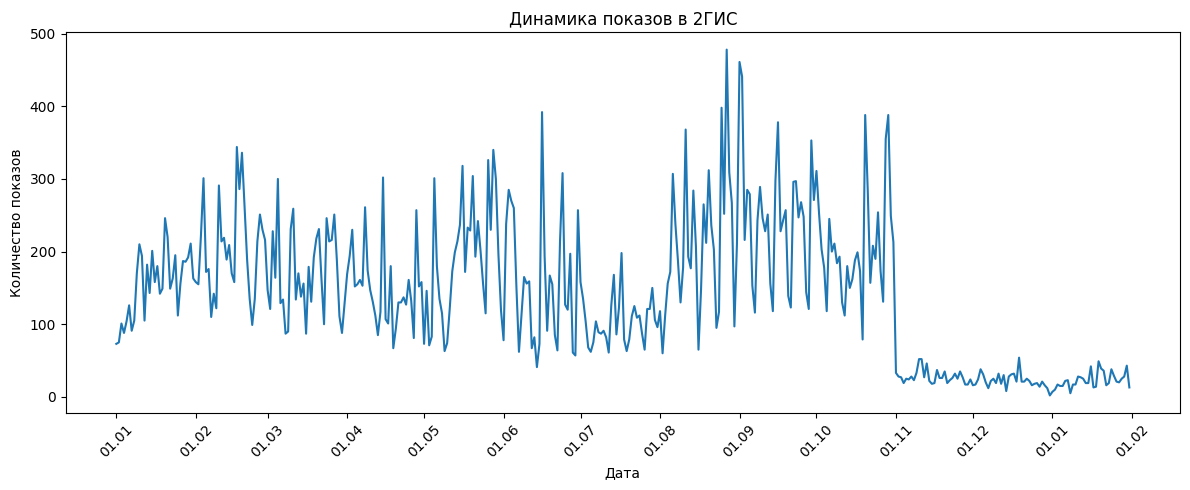

In [8]:
# убираем выброс

clean_gis = gis[gis['Показы'] < 1000]

# чистый график (без выброса)

plt.figure(figsize=(12,5))
plt.plot(clean_gis['Дата'], clean_gis['Показы'])
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.xticks(rotation=45)
plt.ylabel('Количество показов')
plt.xlabel('Дата')
plt.title('Динамика показов в 2ГИС')
plt.tight_layout()
plt.show()

#### Динамика показов
- В начале года показы стабильные, значения в основном в диапазоне 100–300, есть обычные колебания
- В конце марта - аномалия (3500 показов)
- После пика всё возвращается к норме, показы снова около 100-300
- В летний период (в июле) видна легкая просадка
- С августа/сентября видно увеличение, больше дней с высокими показами. Скорее всего связано с началом учебного года и ростом интереса
- С ноября показы почти обнуляются (значения 0-20), падение связано скорее всего с отключением рекламы в этот период

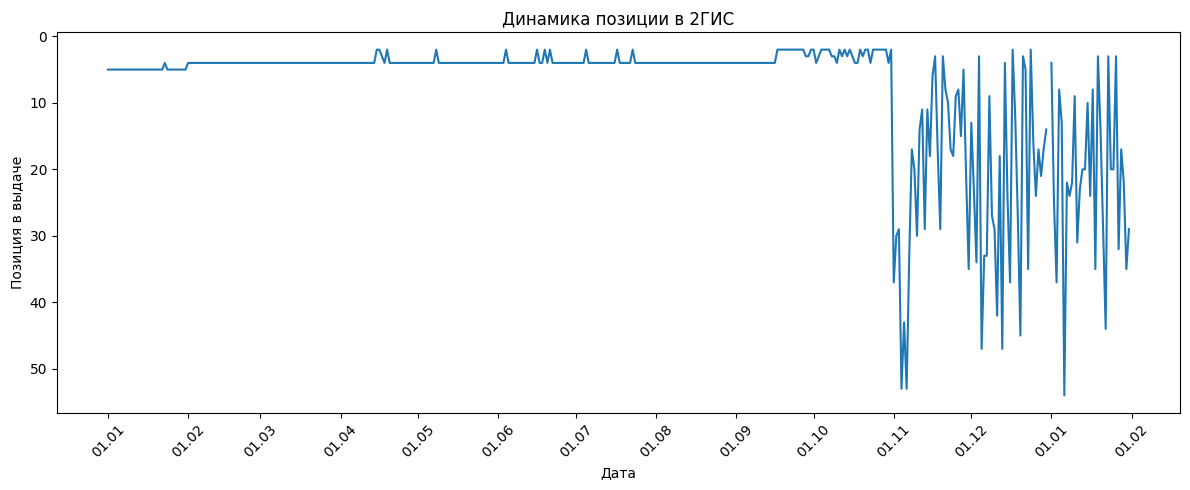

In [9]:
# анализ позиции

plt.figure(figsize=(12,5))
plt.plot(gis['Дата'], gis['Позиция в выдаче'])
plt.gca().invert_yaxis()
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.xticks(rotation=45)
plt.ylabel('Позиция в выдаче')
plt.xlabel('Дата')
plt.title('Динамика позиции в 2ГИС')
plt.tight_layout()
plt.show()

#### Динамика позиции
- Почти весь год позиция стабильная, держится примерно в районе 4–6 места
- Резкий обвал позиции в ноябре (диапазон 10-50), скорее всего связано с отключением рекламы в этот период
- Так как в ноябре упали и показы, то можно сделать вывод о сильной корреляции между позицией и показами (позиция упали → показы упали)
- Сильная нестабильность после падения, позиция постоянно скачет, карточка потеряла устойчивое ранжирование

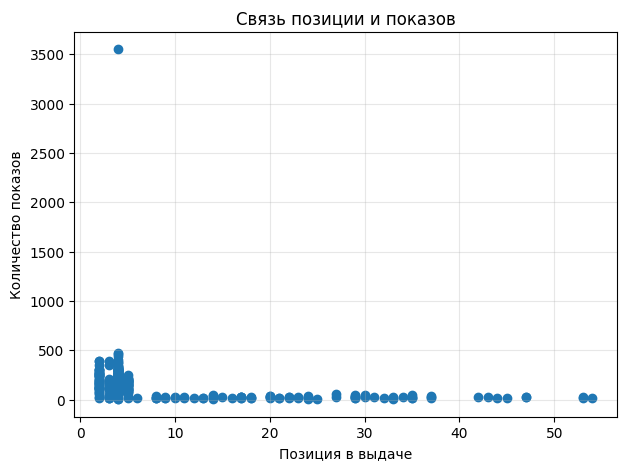

In [10]:
# связь позиции и показов

plt.figure(figsize=(7,5))
plt.scatter(gis['Позиция в выдаче'], gis['Показы'])
plt.xlabel('Позиция в выдаче')
plt.ylabel('Количество показов')
plt.title('Связь позиции и показов')
plt.grid(alpha=0.3)
plt.show()

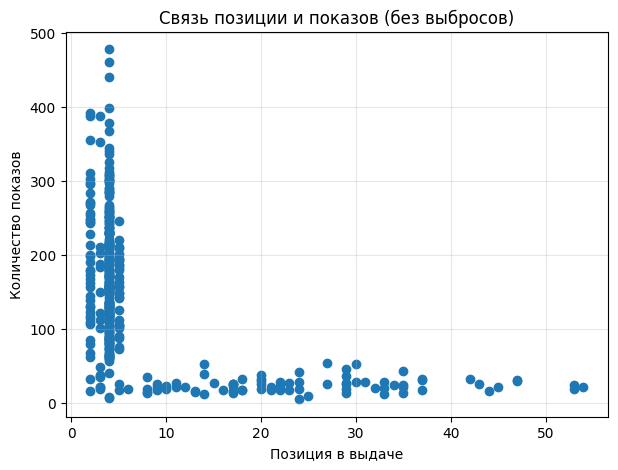

In [11]:
# чистый график (без выброса)

plt.figure(figsize=(7,5))
plt.scatter(clean_gis['Позиция в выдаче'], clean_gis['Показы'])
plt.xlabel('Позиция в выдаче')
plt.ylabel('Количество показов')
plt.title('Связь позиции и показов (без выбросов)')
plt.grid(alpha=0.3)
plt.show()

#### Связь позиции и показов
- Есть чёткая зависимость между позицией и показами
- Позиция напрямую влияет на видимость карточки
- При позиции 1–5 - высокие показы (100–400)
- Порог видимости - при позиции 7–10. При позиции ниже этого порога показы резко падают (10–40)
- Даже при одинаковой позиции показы разные. Позиция важна, но это не единственный фактор показов. Также могут влиять спрос, сезонность по месяцам и дням недели, маркетинговые кампании и т.д.

In [12]:
# пики спроса по дням недели

gis['Дата'] = pd.to_datetime(gis['Дата'], dayfirst=True)
gis['День'] = gis['Дата'].dt.day_name()

gis.groupby('День')['Показы'].mean()

День
Friday       141.561404
Monday       245.892857
Saturday      95.315789
Sunday        94.589286
Thursday     152.280702
Tuesday      173.750000
Wednesday    160.491228
Name: Показы, dtype: float64

#### Пики спроса по дням недели
- В понедельник люди чаще всего ищут школу
- В начале недели выше спрос
- Интерес начинает снижаться к концу недели (к пятнице), в выходные школу ищут редко
- Соответственно, рекламу, акции и посты/контент лучше всего выпускать в начале недели

In [13]:
# пики показов (проверяем в эти дни: рекламные кампании, акции, события)
gis.sort_values('Показы', ascending=False).head(10)

,Дата,Показы,Позиция в выдаче,Затраты,MA_7,День
89,2025-03-31,3550,4.0,0.0,659.714286,Monday
238,2025-08-27,478,4.0,0.0,254.142857,Wednesday
243,2025-09-01,461,4.0,0.0,296.428571,Monday
244,2025-09-02,441,4.0,0.0,323.428571,Tuesday
236,2025-08-25,398,4.0,0.0,224.714286,Monday
166,2025-06-16,392,2.0,0.0,138.571429,Monday
292,2025-10-20,388,3.0,0.0,191.285714,Monday
301,2025-10-29,388,2.0,0.0,242.714286,Wednesday
258,2025-09-16,378,4.0,0.0,239.142857,Tuesday
222,2025-08-11,368,4.0,0.0,225.714286,Monday


#### Пики показов
- 31 марта случился аномальный всплеск показов
- В обычные дни максимум около 400–480 показов
- Самые высокие значения - при хороших позициях

In [14]:
gis['CPI'] = (gis['Затраты'] / gis['Показы']).where(gis['Затраты'] > 0)

gis[gis['Затраты'] > 0][['Дата', 'Показы', 'Затраты', 'CPI']]

,Дата,Показы,Затраты,CPI
85,2025-03-27,251,53003.25,211.168327


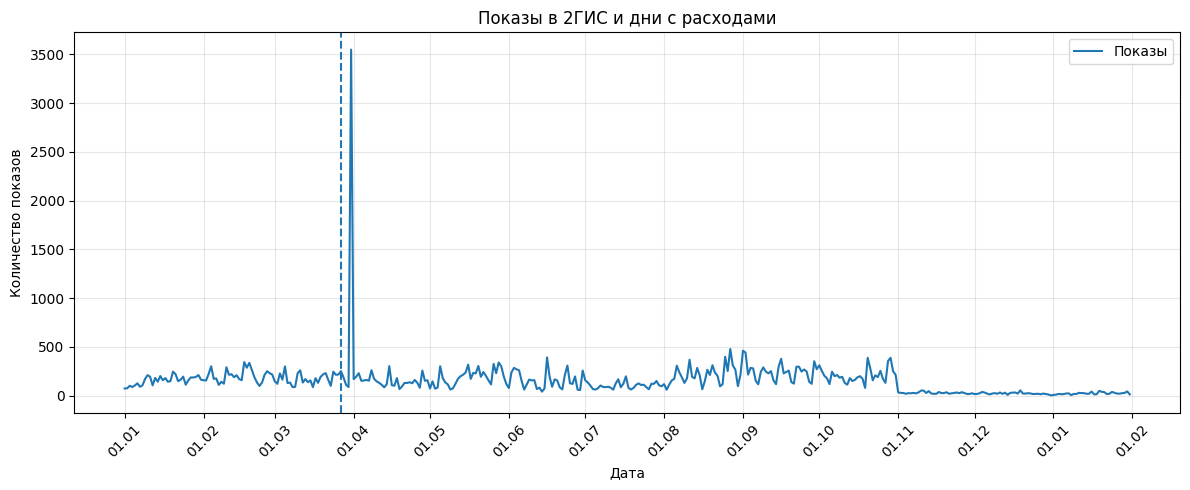

In [15]:
plt.figure(figsize=(12,5))
plt.plot(gis['Дата'], gis['Показы'], label='Показы')

# отмечаем рекламные дни
for d in gis.loc[gis['Затраты'] > 0, 'Дата']:
    plt.axvline(d, linestyle='--')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.xticks(rotation=45)

plt.title('Показы в 2ГИС и дни с расходами')
plt.xlabel('Дата')
plt.ylabel('Количество показов')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

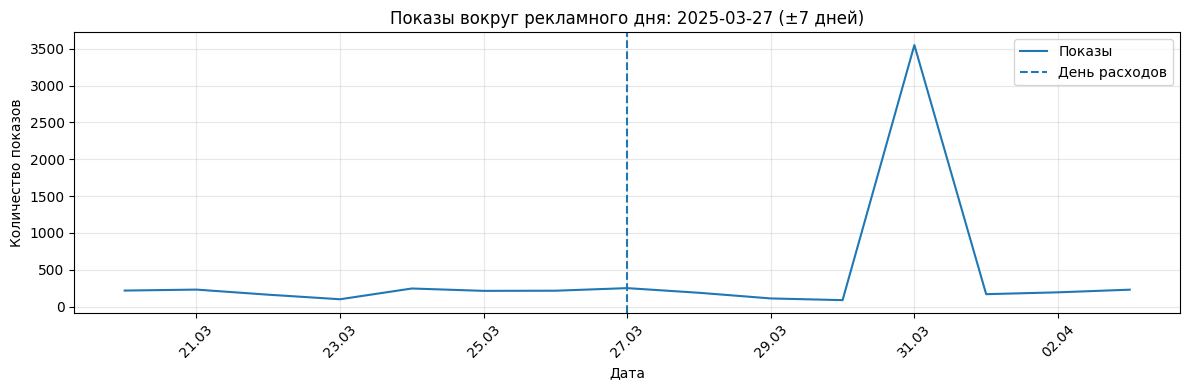

In [16]:
window = 7

for d in gis.loc[gis['Затраты'] > 0, 'Дата']:
    left = d - pd.Timedelta(days=window)
    right = d + pd.Timedelta(days=window)

    segment = gis[(gis['Дата'] >= left) & (gis['Дата'] <= right)].copy()

    plt.figure(figsize=(12,4))
    plt.plot(segment['Дата'], segment['Показы'], label='Показы')
    plt.axvline(d, linestyle='--', label='День расходов')

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    plt.xticks(rotation=45)

    plt.title(f'Показы вокруг рекламного дня: {d.date()} (±{window} дней)')
    plt.xlabel('Дата')
    plt.ylabel('Количество показов')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Анализ расходов
- CPI = 211₽ за показ
- Пик показов не совпал с днём расходов
- Возможные объяснения:
    - Реклама дала отложенный эффект (алгоритм начал активнее показывать карточку позже)
    - Аномалия показов не связана с рекламой

## Яндекс.Бизнес

### Загрузка и предобработка данных

In [17]:
# Просмотры рекламы
ads_views = pd.read_excel("./data/soultune/yandex/Просмотры рекламы.xlsx").T

# приведение данных
ads_views = ads_views.reset_index()
ads_views.columns = ['Дата', 'Просмотры рекламы']
ads_views = ads_views.iloc[1:-1]

# приведение к типам данных
ads_views['Просмотры рекламы'] = pd.to_numeric(ads_views['Просмотры рекламы'])
ads_views['Дата'] = pd.to_datetime(ads_views['Дата'])

ads_views.head()

,Дата,Просмотры рекламы
1,2025-01-01,0
2,2025-01-02,0
3,2025-01-03,0
4,2025-01-04,0
5,2025-01-05,0


In [18]:
ads_views.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 1 to 396
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Дата               396 non-null    datetime64[ns]
 1   Просмотры рекламы  396 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 6.3 KB


In [19]:
# Переходы
clicks = pd.read_excel("./data/soultune/yandex/Переходы.xlsx").T

# приведение данных
clicks = clicks.reset_index()
clicks.columns = ['Дата', 'Переходы']
clicks = clicks.iloc[1:-1]

# приведение к типам данных
clicks['Переходы'] = pd.to_numeric(clicks['Переходы'])
clicks['Дата'] = pd.to_datetime(clicks['Дата'])

clicks.head()

,Дата,Переходы
1,2025-01-01,0
2,2025-01-02,0
3,2025-01-03,0
4,2025-01-04,0
5,2025-01-05,0


In [20]:
clicks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 1 to 396
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Дата      396 non-null    datetime64[ns]
 1   Переходы  396 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 6.3 KB


In [21]:
# Источники переходов в профиль компании
traffic_sources = pd.read_excel("./data/soultune/yandex/Источники переходов в профиль компании.xlsx").T

# приведение данных
traffic_sources = traffic_sources.reset_index()
traffic_sources.columns = traffic_sources.iloc[0]
traffic_sources = traffic_sources.drop(traffic_sources.index[0])
traffic_sources = traffic_sources.reset_index(drop=True)
traffic_sources = traffic_sources.rename(columns={traffic_sources.columns[0]: 'Дата'})
traffic_sources = traffic_sources.iloc[:-1]

# приведение к типам данных
traffic_sources['Дата'] = pd.to_datetime(traffic_sources['Дата'])
for col in traffic_sources.columns[1:]:
    traffic_sources[col] = pd.to_numeric(traffic_sources[col])

traffic_sources.head()

,Дата,Яндекс Поиск,Яндекс Карты,Яндекс Навигатор
0,2025-01-01,1,0,0
1,2025-01-02,1,0,0
2,2025-01-03,0,0,0
3,2025-01-04,2,0,0
4,2025-01-05,0,0,0


In [22]:
traffic_sources.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Дата              396 non-null    datetime64[ns]
 1   Яндекс Поиск      396 non-null    int64         
 2   Яндекс Карты      396 non-null    int64         
 3   Яндекс Навигатор  396 non-null    int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 12.5 KB


In [23]:
# Целевые действия пользователей в Картах
map_conversions = pd.read_excel("./data/soultune/yandex/Целевые действия пользователей в Картах.xlsx").T

# приведение данных
map_conversions = map_conversions.reset_index()
map_conversions.columns = map_conversions.iloc[0]
map_conversions = map_conversions.drop(map_conversions.index[0])
map_conversions = map_conversions.reset_index(drop=True)
map_conversions = map_conversions.rename(columns={map_conversions.columns[0]: 'Дата'})
map_conversions = map_conversions.iloc[:-1]

# приведение к типам данных
map_conversions['Дата'] = pd.to_datetime(map_conversions['Дата'])
for col in map_conversions.columns[1:]:
    map_conversions[col] = pd.to_numeric(map_conversions[col])

map_conversions.head()

,Дата,Переходы на сайт из Карт,Клики по телефону в Картах,Построение маршрута в Картах,Переход по кнопке действия из Карт,Просмотр акции в Картах
0,2025-01-01,0,0,0,0,0
1,2025-01-02,0,0,0,0,0
2,2025-01-03,0,0,0,0,0
3,2025-01-04,0,0,0,0,0
4,2025-01-05,0,0,0,0,0


In [24]:
map_conversions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 6 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Дата                                396 non-null    datetime64[ns]
 1   Переходы на сайт из Карт            396 non-null    int64         
 2   Клики по телефону в Картах          396 non-null    int64         
 3   Построение маршрута в Картах        396 non-null    int64         
 4   Переход по кнопке действия из Карт  396 non-null    int64         
 5   Просмотр акции в Картах             396 non-null    int64         
dtypes: datetime64[ns](1), int64(5)
memory usage: 18.7 KB


In [25]:
# Целевые действия пользователей на сайте
website_conversions = pd.read_excel("./data/soultune/yandex/Целевые действия пользователей на сайте.xlsx").T

# приведение данных
website_conversions = website_conversions.reset_index()
website_conversions.columns = website_conversions.iloc[0]
website_conversions = website_conversions.drop(website_conversions.index[0])
website_conversions = website_conversions.reset_index(drop=True)
website_conversions = website_conversions.rename(columns={website_conversions.columns[0]: 'Дата'})
website_conversions.columns = [
    f"{col}_{i}" if website_conversions.columns.tolist().count(col) > 1 else col
    for i, col in enumerate(website_conversions.columns)]
website_conversions = website_conversions.iloc[:-1]

# приведение типов данных
website_conversions['Дата'] = pd.to_datetime(website_conversions['Дата'])
for col in website_conversions.columns[1:]:
    website_conversions[col] = pd.to_numeric(website_conversions[col])

website_conversions.head()

,Дата,Переход в мессенджер,Заявка,Клик по номеру телефона,Отправка формы_4,Отправка формы_5,Отправка формы_6,Отправка формы_7,Клик по телефону,Заполнил контактные данные,Клик по email,Отправил контактные данные,Переход в соц.сеть,Поиск по сайту,Записаться онлайн
0,2025-01-01,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2025-01-02,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2025-01-03,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2025-01-04,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2025-01-05,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [26]:
website_conversions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Дата                        396 non-null    datetime64[ns]
 1   Переход в мессенджер        396 non-null    int64         
 2   Заявка                      396 non-null    int64         
 3   Клик по номеру телефона     396 non-null    int64         
 4   Отправка формы_4            396 non-null    int64         
 5   Отправка формы_5            396 non-null    int64         
 6   Отправка формы_6            396 non-null    int64         
 7   Отправка формы_7            396 non-null    int64         
 8   Клик по телефону            396 non-null    int64         
 9   Заполнил контактные данные  396 non-null    int64         
 10  Клик по email               396 non-null    int64         
 11  Отправил контактные данные  396 non-null    int64         

In [27]:
# Что делали в профиле компании
profile_conversions = pd.read_excel("./data/soultune/yandex/Что делали в профиле компании.xlsx").T

# приведение данных
profile_conversions = profile_conversions.reset_index()
profile_conversions.columns = profile_conversions.iloc[0]
profile_conversions = profile_conversions.drop(profile_conversions.index[0])
profile_conversions = profile_conversions.reset_index(drop=True)
profile_conversions = profile_conversions.rename(columns={profile_conversions.columns[0]: 'Дата'})
profile_conversions = profile_conversions.iloc[:-1]

# приведение типов данных
profile_conversions['Дата'] = pd.to_datetime(profile_conversions['Дата'])
for col in profile_conversions.columns[1:]:
    profile_conversions[col] = pd.to_numeric(profile_conversions[col])

profile_conversions.head()

,Дата,Переходы на сайт,Проложено маршрутов,Нажатий «Позвонить»
0,2025-01-01,0,0,0
1,2025-01-02,0,0,0
2,2025-01-03,0,0,0
3,2025-01-04,0,0,0
4,2025-01-05,0,0,0


In [28]:
profile_conversions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Дата                 396 non-null    datetime64[ns]
 1   Переходы на сайт     396 non-null    int64         
 2   Проложено маршрутов  396 non-null    int64         
 3   Нажатий «Позвонить»  396 non-null    int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 12.5 KB


In [29]:
# Длительность звонков
call_metrics = pd.read_excel("./data/soultune/yandex/Длительность звонков.xlsx").T

# приведение данных
call_metrics = call_metrics.reset_index()
call_metrics.columns = call_metrics.iloc[0]
call_metrics = call_metrics.drop(call_metrics.index[0])
call_metrics = call_metrics.reset_index(drop=True)
call_metrics = call_metrics.rename(columns={call_metrics.columns[0]: 'Дата'})
call_metrics = call_metrics.iloc[:-1]

# приведение типов данных
call_metrics['Дата'] = pd.to_datetime(call_metrics['Дата'])
for col in call_metrics.columns[1:]:
    call_metrics[col] = pd.to_timedelta(
        call_metrics[col].astype(str),
        errors='coerce'
    )

call_metrics.head()

,Дата,Длительность разговора,Длительность ожидания
0,2025-01-01,0 days,0 days
1,2025-01-02,0 days,0 days
2,2025-01-03,0 days,0 days
3,2025-01-04,0 days,0 days
4,2025-01-05,0 days,0 days


In [30]:
call_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype          
---  ------                  --------------  -----          
 0   Дата                    396 non-null    datetime64[ns] 
 1   Длительность разговора  396 non-null    timedelta64[ns]
 2   Длительность ожидания   396 non-null    timedelta64[ns]
dtypes: datetime64[ns](1), timedelta64[ns](2)
memory usage: 9.4 KB


In [31]:
# Статистика по звонкам
call_logs = pd.read_excel("./data/soultune/yandex/Статистика по звонкам.xlsx")

call_logs.head()

,Время звонка,Оригинальный номер,Подменный номер,Номер звонившего,Продолжительность разговора,Результат звонка
0,2026-02-08 07:53:35.733,79587617976,79652299459,79830335534,0,Не было ответа
1,2026-02-08 07:22:06.293,79587617976,79652299459,79830335534,0,Не было ответа
2,2026-01-29 09:03:24.312,79587617976,79652299459,74951698648,17,Успешный звонок
3,2026-01-25 06:56:11.833,79587617976,79652299459,79139229542,6,Успешный звонок
4,2026-01-25 06:13:26.631,79587617976,79652299459,79134241876,0,Не было ответа


In [32]:
call_logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Время звонка                 24 non-null     datetime64[ns]
 1   Оригинальный номер           24 non-null     int64         
 2   Подменный номер              24 non-null     int64         
 3   Номер звонившего             24 non-null     int64         
 4   Продолжительность разговора  24 non-null     int64         
 5   Результат звонка             24 non-null     object        
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 1.3+ KB


### Исследовательский анализ данных

In [33]:
df = ads_views.merge(clicks, on='Дата', how='left')
df = df.merge(traffic_sources, on='Дата', how='left')
df = df.merge(profile_conversions, on='Дата', how='left')
df = df.merge(map_conversions, on='Дата', how='left')
df = df.merge(website_conversions, on='Дата', how='left')
df = df.merge(call_metrics, on='Дата', how='left')

In [34]:
df['CTR'] = df['Переходы'] / df['Просмотры рекламы']
df['CTR'] = df['CTR'].replace([np.inf, -np.inf], 0)

In [35]:
df['Лиды_звонки'] = (
    df['Нажатий «Позвонить»'] +
    df['Клик по телефону']
)

df['Лиды_сайт'] = (
    df['Отправка формы_4'] +
    df['Заполнил контактные данные']
)

df['Лиды_сообщения'] = df['Переход в мессенджер']

df['Лиды_итого'] = (
    df['Лиды_звонки'] +
    df['Лиды_сайт'] +
    df['Лиды_сообщения']
)

In [36]:
df['CTR'] = df['Переходы'] / df['Просмотры рекламы']
df['CR_клик'] = df['Лиды_итого'] / df['Переходы']
df['CR_показ'] = df['Лиды_итого'] / df['Просмотры рекламы']

df = df.replace([np.inf, -np.inf], 0)

In [37]:
# что приносит лиды
df.corr(numeric_only=True)['Лиды_итого'].sort_values(ascending=False)

Лиды_итого                            1.000000
Лиды_сообщения                        0.964770
Переход в мессенджер                  0.964770
Заявка                                0.946275
CR_клик                               0.699948
CR_показ                              0.521008
Переходы                              0.463841
Клик по номеру телефона               0.408492
Отправка формы_6                      0.318002
Отправка формы_4                      0.318002
Отправка формы_5                      0.318002
Отправка формы_7                      0.318002
Лиды_сайт                             0.317019
Клик по телефону                      0.305463
Лиды_звонки                           0.298850
Просмотры рекламы                     0.287058
Заполнил контактные данные            0.192601
Нажатий «Позвонить»                   0.116616
Отправил контактные данные            0.103978
CTR                                   0.099238
Яндекс Поиск                          0.097440
Клики по теле

In [38]:
# доли типов лидов
df[['Лиды_звонки', 'Лиды_сайт', 'Лиды_сообщения']].sum()

Лиды_звонки        33
Лиды_сайт          43
Лиды_сообщения    579
dtype: int64

**Вывод**: основной драйвер лидов - мессенджеры

**Рекомендации**:
- добавить WhatsApp и другие способы связи, помимо Telegram
- добавить автоответы (т.к. переходов в мессенджер больше, чем заявок)
- увеличение скорости реакции на сообщения

In [39]:
# анализ звонков

call_logs['Успешный'] = call_logs['Результат звонка'] == 'Успешный звонок'

success_rate = call_logs['Успешный'].mean()
avg_duration = call_logs['Продолжительность разговора'].mean()

success_rate, avg_duration

(np.float64(0.25), np.float64(15.833333333333334))

- Успешных звонков всего 25%
- Средняя длительность - около 16 секунд
- Как вывод: звонки - слабый канал, возможные причины:
    - люди случайно кликают
    - нецелевой трафик
    - плохой оффер
    - неудобное время звонков
    - качество обработки

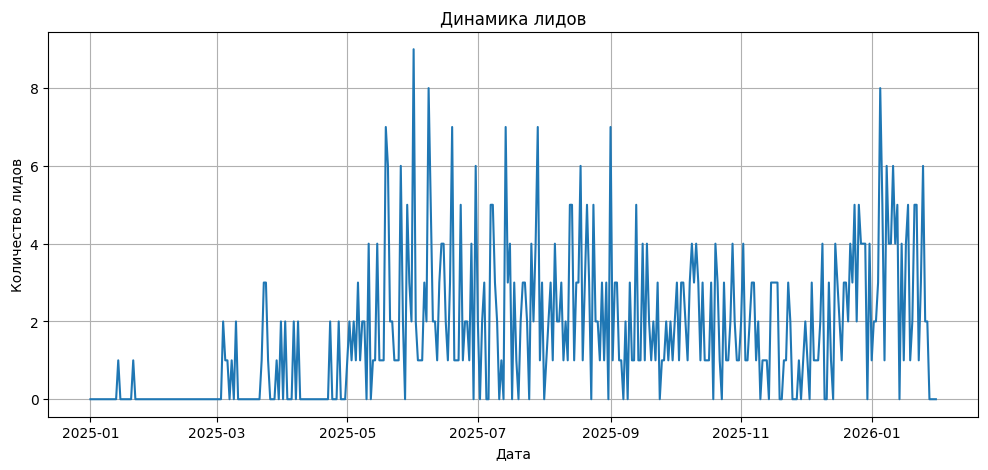

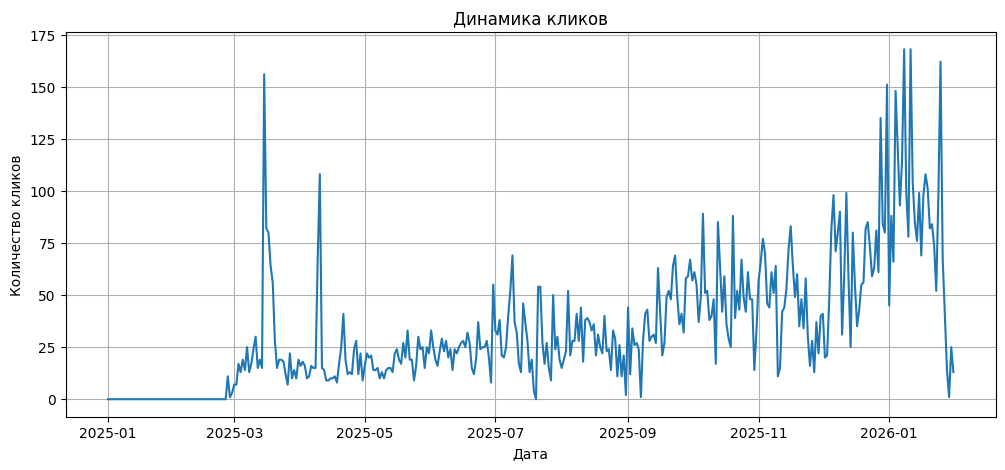

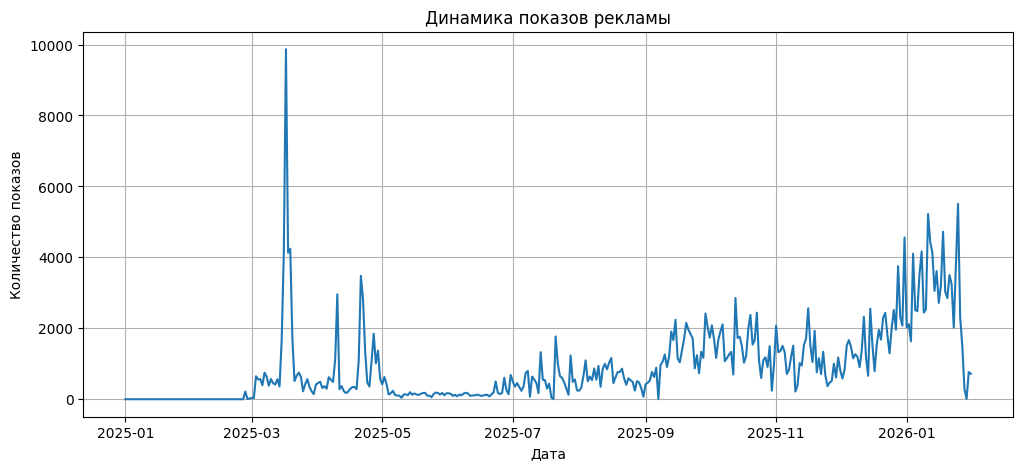

In [40]:
# лиды vs реклама

# лиды
plt.figure(figsize=(12,5))
plt.plot(df['Дата'], df['Лиды_итого'])

plt.title('Динамика лидов')
plt.xlabel('Дата')
plt.ylabel('Количество лидов')
plt.grid()
plt.show()

# клики
plt.figure(figsize=(12,5))
plt.plot(df['Дата'], df['Переходы'])

plt.title('Динамика кликов')
plt.xlabel('Дата')
plt.ylabel('Количество кликов')
plt.grid()
plt.show()

# показы
plt.figure(figsize=(12,5))
plt.plot(df['Дата'], df['Просмотры рекламы'])

plt.title('Динамика показов рекламы')
plt.xlabel('Дата')
plt.ylabel('Количество показов')
plt.grid()
plt.show()

- По количеству лидов пик приходится на летний период, в январе-феврале - минимум
- По кликам - рост к концу периода, значит, реклама усиливается / масштабируется
- По показам рекламы: виден сильный рост охвата, видны резкие всплески (вероятно изменение кампаний), но лиды при этом не взлетают пропорционально
- **Вывод**: масштабирование рекламы не приводит к масштабированию лидов, возможные причины:
    - падает качество трафика
    - ограничение спроса (рынок насыщается)
    - проблема конверсии (сайт / оффер)

## CRM "Мой Класс"

### Загрузка данных

In [41]:
# Клиенты (все ученики студии)
clients = pd.read_csv("./data/soultune/CRM/clients.csv")

clients.head()

,id,name,email,phone,advSourceId,balans,bonusBalance,availableBalance,createSourceId,statusChangeReasonId,stateChangedAt,clientStateId,createdAt,updatedAt,filials,responsibles,attributes,joins,tags
0,6421631,Гарсия Платон,NaN,NaN,NaN,NaN,0,NaN,1,NaN,2024-11-03T09:46:15+00:00,257526,2024-10-12T19:19:13+00:00,2024-11-03T09:46:15+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...",[],"[{'id': 87912, 'name': 'Проверить'}]"
1,6421632,Сафаров Амир,NaN,ph_202754a1b475,NaN,NaN,0,NaN,1,NaN,2024-11-03T09:45:59+00:00,257526,2024-10-12T19:19:13+00:00,2024-11-03T09:45:59+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...",[],"[{'id': 87912, 'name': 'Проверить'}]"
2,6421633,Валиев Хакан,NaN,ph_6f516681124a,NaN,NaN,0,NaN,1,NaN,2024-10-18T09:40:33+00:00,257524,2024-10-12T19:19:13+00:00,2024-10-18T09:40:33+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...",[],[]
3,6421634,Асланов Амир,NaN,ph_7f3912774b71,NaN,NaN,0,NaN,1,NaN,2024-11-03T09:45:55+00:00,257526,2024-10-12T19:19:13+00:00,2024-11-03T09:45:55+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...",[],"[{'id': 87912, 'name': 'Проверить'}]"
4,6421635,Ермолаев Емельян,NaN,ph_7851d3e84643,NaN,NaN,0,NaN,1,NaN,2024-11-03T09:45:47+00:00,257526,2024-10-12T19:19:13+00:00,2024-11-03T09:45:47+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...",[],"[{'id': 87912, 'name': 'Проверить'}]"


In [42]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 865 entries, 0 to 864
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    865 non-null    int64  
 1   name                  865 non-null    object 
 2   email                 40 non-null     object 
 3   phone                 783 non-null    object 
 4   advSourceId           155 non-null    float64
 5   balans                189 non-null    float64
 6   bonusBalance          865 non-null    int64  
 7   availableBalance      189 non-null    float64
 8   createSourceId        865 non-null    int64  
 9   statusChangeReasonId  78 non-null     float64
 10  stateChangedAt        814 non-null    object 
 11  clientStateId         865 non-null    int64  
 12  createdAt             865 non-null    object 
 13  updatedAt             865 non-null    object 
 14  filials               865 non-null    object 
 15  responsibles          8

**Описание**
| Поле | Тип | Описание |
|------|-----|----------|
| `id` | int | **Первичный ключ.** Уникальный идентификатор клиента в CRM |
| `name` | str | Имя и фамилия клиента. **Анонимизировано** — заменено на вымышленное по первой букве |
| `phone` | str | Телефон в формате `ph_xxxxxxxxxxxx`. **Захеширован.** Один и тот же номер даёт один и тот же хеш во всех таблицах — можно джойнить с `leads.phone` и `calls.from` |
| `email` | str | Email в формате `xxxxxxxxxxxx@anon.local`. **Захеширован** |
| `birthDate` | date | Дата рождения клиента (формат `YYYY-MM-DD`). Настоящая, не анонимизирована |
| `createdAt` | datetime | Дата и время создания карточки клиента в CRM |
| `statusId` | int | Идентификатор статуса клиента (например: активный, неактивный, архивный). Расшифровки статусов нет — нужно восстановить по данным |
| `filialIds` | list/str | Идентификаторы филиалов, к которым привязан клиент |
| `responsibleId` | int | ID ответственного сотрудника (FK → staff.id) |
| `source` | str | Источник привлечения клиента (например: «2ГИС», «сайт», «сарафан», «Яндекс») |
| `comment` | str | Заменён на `—`. В оригинале содержал свободный текст с персданными |
| `advSourceId` | int | ID рекламного источника |

> **Подсказка:** Поле `phone` — главный ключ для связи клиентов с лидами и звонками. Связь через `id` работает только внутри CRM.

In [43]:
# Записи клиентов в группы (факт записи ученика в конкретную группу)
joins_records = pd.read_csv("./data/soultune/CRM/joins_records.csv")

joins_records.head()

,id,userId,classId,courseId,price,statusId,stateChangedAt,statusChangeReasonId,autoJoin,autoDebit,...,stats.totalPayed,stats.nonPayedLessons,params.nextPay.enabled,params.nextPay.sumType,params.invoices.autoCreate,params.invoices.createRule,params.invoices.joinStateId,params.invoices.payDateDays,params.invoices.payDateType,params.nextPay.payUntilPeriod
0,7354835,6653882,534888,0,NaN,2,2024-11-18T09:56:20+00:00,NaN,True,False,...,30800,5,False,full,True,setStatus,[],3.0,relative,NaN
1,7355052,6421689,534888,0,NaN,2,2024-11-18T10:14:12+00:00,NaN,True,False,...,7500,0,False,full,NaN,NaN,NaN,NaN,NaN,NaN
2,7355268,6687365,534888,0,NaN,2,2024-11-18T10:31:04+00:00,NaN,True,False,...,40000,10,False,full,True,setStatus,[],3.0,relative,NaN
3,7355376,6648362,534888,0,NaN,2,2024-11-18T10:40:19+00:00,NaN,True,False,...,6300,0,False,full,True,setStatus,[],3.0,relative,NaN
4,7357882,6561173,535039,0,NaN,86063,2024-11-18T14:37:49+00:00,NaN,True,False,...,11400,0,False,full,True,setStatus,[],3.0,relative,NaN


In [44]:
joins_records.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id                             163 non-null    int64  
 1   userId                         163 non-null    int64  
 2   classId                        163 non-null    int64  
 3   courseId                       163 non-null    int64  
 4   price                          0 non-null      float64
 5   statusId                       163 non-null    int64  
 6   stateChangedAt                 163 non-null    object 
 7   statusChangeReasonId           6 non-null      float64
 8   autoJoin                       163 non-null    bool   
 9   autoDebit                      163 non-null    bool   
 10  managerId                      163 non-null    int64  
 11  remindSum                      0 non-null      float64
 12  remindDate                     0 non-null      flo

| Поле joins_records | Тип | Описание (собственное) |
|------|-----|----------|
| `id` | int | ID абонемента **(первичный ключ)** |
| `userId` | int | ID клиента (FK → `clients.id`) |
| `classId` | int | Тип абонемента |
| `courseId` | int | Направление абонемента (гитара, вокал и т.д.) |
| `price` | float | Стоимость |
| `statusId` | int | Статус записи (например: активна, отменена, завершена) |
| `stateChangedAt` | object | Когда статус изменился |
| `statusChangeReasonId` | float | Причина изменения статуса |
| `autoJoin` | bool | Автопродление абонемента |
| `autoDebit` | bool | Автоплатёж |
| `managerId` | int | ID менеджера, оформившего запись (FK → `staff.id`) |
| `remindSum` | float | Напоминания об оплате / задолженность |
| `remindDate` | float | Напоминания об оплате / задолженность |
| `comment` | str | Заменён на `—` |
| `advSourceId` | float | ID рекламного источника |
| `createSourceId` | int | Источник создания записи / клиента |
| `tags` | object | Теги записи |
| `createdAt` | object | Дата записи в группу |
| `updatedAt` | object | Когда абонемент был изменен |
| `invoices` | object | Счета |
| `stats.visits` | int | Сколько занятий посетил клиент |
| `stats.freeVisits` | int | Бесплатные занятия |
| `stats.nextRecord` | object | Будущая запись |
| `stats.lastVisit` | object | Последнее посещение |
| `stats.lessonsLost` | int | Сгоревшие занятия |
| `stats.totalPayed` | int | Всего оплачено по абонементу |
| `stats.nonPayedLessons` | int | Неоплаченные занятия |
| `params.nextPay.enabled` | bool | Включён ли автоплатёж |
| `params.nextPay.sumType` | object | Тип суммы следующего платежа |
| `params.invoices.autoCreate` | object | Автоматически ли создаются счета |
| `params.invoices.createRule` | object | Правило создания счёта |
| `params.invoices.joinStateId` | object | Статус абонемента для логики счетов |
| `params.invoices.payDateDays` | float | Через сколько дней оплатить счёт |
| `params.invoices.payDateType` | object | Тип даты оплаты (до урока, после урока и т.д.) |
| `params.nextPay.payUntilPeriod` | float | Период продления автоплатежа |

In [45]:
# удаление 'comment', т.к. не несет смысловую нагрузку
# удаление 'price', 'remindSum', 'remindDate', 'params.nextPay.payUntilPeriod', т.к. отсутствуют записи
joins_records = joins_records.drop(
    columns=[
        'comment',
        'price',
        'remindSum',
        'remindDate',
        'params.nextPay.payUntilPeriod'
    ]
)

In [46]:
joins_records['stats.visits'] = pd.to_datetime(joins_records['stats.visits'], errors='coerce')

In [47]:
# Абонементы (купленные клиентами пакеты занятий, один клиент может иметь несколько абонементов)
subscriptions = pd.read_csv("./data/soultune/CRM/subscriptions.csv")

pd.set_option('display.max_columns', None)
subscriptions.head(10)

,id,name,type,yield,price,period,courses,classes,autodebit,visitCount,useDiscount,useLeftovers,burnLeftovers,subscriptionGroupingId,filialIds,filialId,family,multi,createdAt,updatedAt,params.courseIds,params.classIds,params.onlinePayment.enabled,params.onlinePayment.beginDateSelectDefault,params.onlinePayment.beginDateSelectEnabled,params.fieldsToShowInNameAsAdditionalInfo,params.autoCreateSettings.payUntil,params.autoCreateSettings.activeFrom,params.autoCreateSettings.autoCreate,params.autoCreateSettings.createTime,params.autoCreateSettings.useDiscount,params.autoCreateSettings.deleteNonPaid,params.autoCreateSettings.payUntilCounter,params.autoCreateSettings.createTimeCounter,params.autoCreateSettings.payUntilCounterType,params.autoCreateSettings.deleteNonPaidCounter
0,174564,Абонемент 4 занятия,limited,1200,5400,1 month,"[-1, 0]","[534888, 535039, 535053, 536064]",True,4,False,True,True,NaN,[0],NaN,True,True,2024-10-22T07:43:09+00:00,2025-02-12T06:32:57+00:00,[],[],True,fromFirstPaidVisit,False,"['price', 'visitCount', 'period']",daysAfterCreation,fromCreate,off,nextDayCurrentEnds,False,True,5.0,1.0,thisMonth,14.0
1,174565,Абонемент 8 занятий,limited,1000,10000,2 month,"[-1, 0]","[534888, 535039, 535053, 536064]",True,8,False,True,True,NaN,[0],NaN,True,True,2024-10-22T07:44:00+00:00,2025-02-12T06:33:12+00:00,[],[],True,fromFirstPaidVisit,False,"['price', 'visitCount', 'period']",daysAfterCreation,fromCreate,off,nextDayCurrentEnds,False,True,5.0,1.0,thisMonth,14.0
2,174566,Абонемент 12 занятий,limited,900,13800,3 month,"[-1, 0]","[534888, 535039, 535053, 536064]",True,12,False,True,True,NaN,[0],NaN,True,True,2024-10-22T07:44:37+00:00,2025-02-12T06:32:26+00:00,[],[],True,fromFirstPaidVisit,False,"['price', 'visitCount', 'period']",daysAfterCreation,fromCreate,off,nextDayCurrentEnds,False,True,5.0,1.0,thisMonth,14.0
3,179102,Пробное занятие,limited,600,600,NaN,"[-1, 0]","[534888, 535039, 535053, 536064]",True,1,False,True,True,NaN,[0],NaN,True,True,2024-11-18T10:46:20+00:00,2024-11-18T10:46:20+00:00,[],[],True,fromNow,False,"['price', 'visitCount', 'period']",daysAfterCreation,fromCreate,off,nextDayCurrentEnds,False,True,5.0,1.0,thisMonth,14.0
4,179780,Без названия,limited,1200,0,NaN,[],[],True,1,False,False,True,NaN,[0],NaN,False,False,2024-11-25T08:47:25+00:00,2024-11-25T08:47:25+00:00,[],[],True,auto,False,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,186921,Без названия,limited,1200,0,NaN,[],[],True,1,False,False,True,NaN,[0],NaN,False,False,2025-01-17T13:22:20+00:00,2025-01-17T13:22:20+00:00,[],[],True,fromFirstPaidVisit,False,[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,202429,Разовое занятие,limited,1400,1400,NaN,"[-1, 0]","[534888, 535039, 535053, 536064]",False,1,False,True,True,NaN,[0],NaN,True,True,2025-05-27T05:36:49+00:00,2025-05-27T05:37:07+00:00,[],[],False,fromFirstPaidVisit,False,"['price', 'visitCount', 'period']",daysAfterCreation,fromCreate,off,nextDayCurrentEnds,False,True,5.0,1.0,thisMonth,14.0


In [48]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 36 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              7 non-null      int64  
 1   name                                            7 non-null      object 
 2   type                                            7 non-null      object 
 3   yield                                           7 non-null      int64  
 4   price                                           7 non-null      int64  
 5   period                                          3 non-null      object 
 6   courses                                         7 non-null      object 
 7   classes                                         7 non-null      object 
 8   autodebit                                       7 non-null      bool   
 9   visitCount                                     

**Описание**
| Поле | Тип | Описание |
|------|-----|----------|
| `id` | int | **Первичный ключ.** Уникальный ID абонемента |
| `userId` | int | ID клиента (FK → `clients.id`) |
| `classId` | int | ID типа абонемента |
| `className` | str | Название типа абонемента (например: «8 занятий вокала», «Безлимит фортепиано») |
| `price` | float | Стоимость абонемента в рублях |
| `sellPrice` | float | Цена, по которой абонемент фактически продан (может отличаться от прайсовой) |
| `visitCount` | int | Сколько занятий входит в абонемент |
| `visitedCount` | int | Сколько занятий клиент уже посетил |
| `beginDate` | date | Дата начала действия абонемента |
| `endDate` | date | Дата окончания действия абонемента |
| `createdAt` | datetime | Дата создания записи абонемента в CRM |
| `statusId` | int | Статус абонемента (активен, истёк, заморожен и т.д.) |
| `filialId` | int | ID филиала |
| `groupId` | int | ID группы, к которой привязан абонемент (FK → `groups.id`) |

> **Подсказка:** Разница между `visitCount` и `visitedCount` покажет сколько занятий осталось. Если `visitedCount > visitCount` — возможны бесплатные пробные или бонусы.

In [49]:
# Занятия (все проведённые и запланированные уроки)
lessons = pd.read_csv("./data/soultune/CRM/lessons.csv")

lessons.head(10)

,id,date,beginTime,endTime,createdAt,filialId,roomId,classId,status,comment,maxStudents,topic,description,teacherIds
0,50574598,2025-01-10,12:00,12:50,2024-11-18T10:31:04+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834]
1,50744315,2025-01-09,16:00,16:50,2024-11-21T10:59:31+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834]
2,50744316,2025-01-16,16:00,16:50,2024-11-21T10:59:31+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834]
3,52001642,2025-01-10,11:00,12:00,2024-12-14T15:42:36+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834]
4,52001643,2025-01-17,11:00,12:00,2024-12-14T15:42:36+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834]
5,52001644,2025-01-24,11:00,12:00,2024-12-14T15:42:36+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834]
6,52001645,2025-01-31,11:00,12:00,2024-12-14T15:42:36+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834]
7,52001646,2025-02-07,11:00,12:00,2024-12-14T15:42:36+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834]
8,52001647,2025-02-14,11:00,12:00,2024-12-14T15:42:36+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834]
9,52001648,2025-02-21,11:00,12:00,2024-12-14T15:42:36+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834]


In [50]:
lessons.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1130 entries, 0 to 1129
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1130 non-null   int64  
 1   date         1130 non-null   object 
 2   beginTime    1130 non-null   object 
 3   endTime      1130 non-null   object 
 4   createdAt    1130 non-null   object 
 5   filialId     1130 non-null   int64  
 6   roomId       1130 non-null   int64  
 7   classId      1130 non-null   int64  
 8   status       1130 non-null   int64  
 9   comment      1 non-null      object 
 10  maxStudents  1130 non-null   int64  
 11  topic        3 non-null      object 
 12  description  0 non-null      float64
 13  teacherIds   1130 non-null   object 
dtypes: float64(1), int64(6), object(7)
memory usage: 123.7+ KB


| Поле | Тип | Описание |
|------|-----|----------|
| `id` | int | **Первичный ключ.** Уникальный ID занятия |
| `date` | date | Дата проведения занятия (`YYYY-MM-DD`) |
| `beginTime` | time | Время начала (например `10:00`) |
| `endTime` | time | Время окончания (например `11:00`) |
| `groupId` | int | ID группы (FK → `groups.id`). Показывает, в рамках какой группы прошло занятие |
| `teacherIds` | list | Список ID преподавателей, которые вели занятие (FK → `staff.id`). Обычно один, но может быть несколько |
| `filialId` | int | ID филиала |
| `roomId` | int | ID аудитории/зала |
| `status` | int | Статус: запланировано, проведено, отменено. Расшифровку определите по данным |
| `maxStudents` | int | Максимальное количество учеников на занятии |
| `topic` | str | Тема занятия (если заполнена преподавателем) |
| `createdAt` | datetime | Дата создания записи |

> **Подсказка:** Разница `endTime - beginTime` = длительность урока. Для расчёта загрузки студии — считайте занятия в разрезе дня недели и времени.

In [51]:
# Платежи (все финансовые операции: оплаты абонементов, разовые, возвраты)
payments = pd.read_csv("./data/soultune/CRM/payments.csv")

payments.head()

,id,userId,summa,date,optype,comment,managerId,invoiceId,userSubscriptionId,paymentTypeId,filialId,cashboxId
0,22832059,6668975,4800,2025-01-05,income,—,164296.0,NaN,NaN,93683.0,55814,NaN
1,22832060,6668975,-4800,2025-01-05,debit,—,NaN,11498547.0,10822333.0,NaN,55814,NaN
2,22840924,6928835,8000,2025-01-06,income,—,164296.0,NaN,NaN,93683.0,55814,NaN
3,22840925,6928835,-8000,2025-01-06,debit,—,NaN,11502674.0,10826387.0,NaN,55814,NaN
4,23048242,6421725,4800,2025-01-14,income,—,164296.0,NaN,NaN,93683.0,55814,NaN


In [52]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  567 non-null    int64  
 1   userId              567 non-null    int64  
 2   summa               567 non-null    int64  
 3   date                567 non-null    object 
 4   optype              567 non-null    object 
 5   comment             567 non-null    object 
 6   managerId           283 non-null    float64
 7   invoiceId           284 non-null    float64
 8   userSubscriptionId  284 non-null    float64
 9   paymentTypeId       283 non-null    float64
 10  filialId            567 non-null    int64  
 11  cashboxId           0 non-null      float64
dtypes: float64(5), int64(4), object(3)
memory usage: 53.3+ KB


| Поле | Тип | Описание |
|------|-----|----------|
| `id` | int | **Первичный ключ.** Уникальный ID платежа |
| `userId` | int | ID клиента (FK → `clients.id`) |
| `subscriptionId` | int | ID абонемента, за который произведена оплата (FK → `subscriptions.id`). Может быть `null` для разовых оплат |
| `summa` | float | Сумма платежа в рублях. **Может быть отрицательной** (возврат) |
| `date` | date | Дата платежа |
| `createdAt` | datetime | Дата создания записи |
| `paymentTypeId` | int | Способ оплаты (наличные, карта, перевод). Расшифровку нужно определить по данным |
| `comment` | str | Заменён на `—` |
| `invoiceId` | int | ID счёта (если оплата через выставленный счёт) |

> **Подсказка:** Для расчёта выручки по месяцам — группируйте по `date`. Отрицательные значения `summa` — это возвраты.

### Исследовательский анализ данных

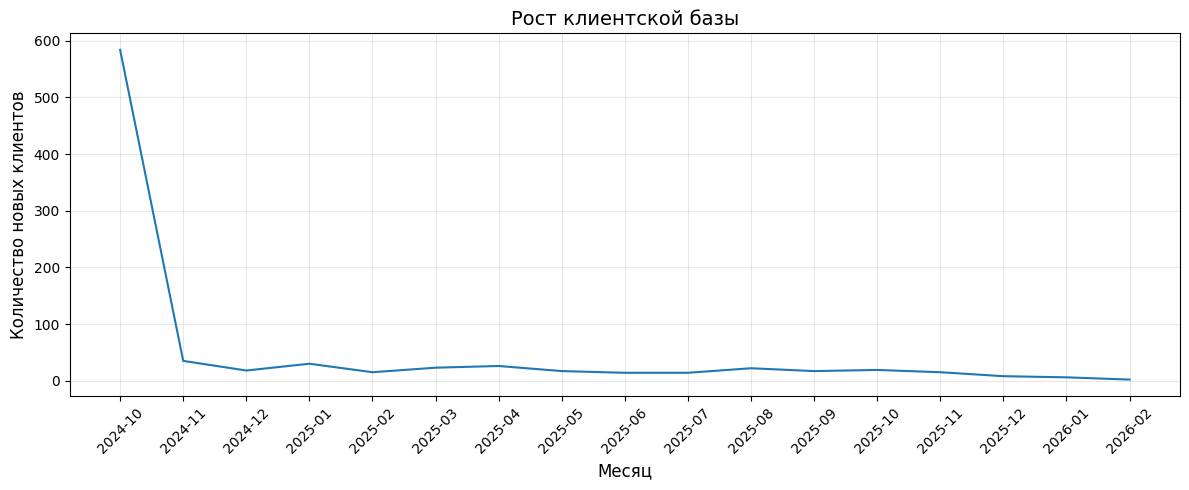

In [53]:
# рост клиентской базы

clients['createdAt'] = pd.to_datetime(clients['createdAt'], errors='coerce')

# УБИРАЕМ timezone → вот ключевая строка
clients['createdAt'] = clients['createdAt'].dt.tz_localize(None)

clients_by_month = clients.groupby(
    clients['createdAt'].dt.to_period('M')
).size()

plt.figure(figsize=(12,5))

plt.plot(clients_by_month.index.astype(str), clients_by_month.values)

plt.title('Рост клиентской базы', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество новых клиентов', fontsize=12)

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- Рост клиенткой базы сильно замедлился после ноября 2024 года
- К концу периода видна тенденция к снижению привлечения

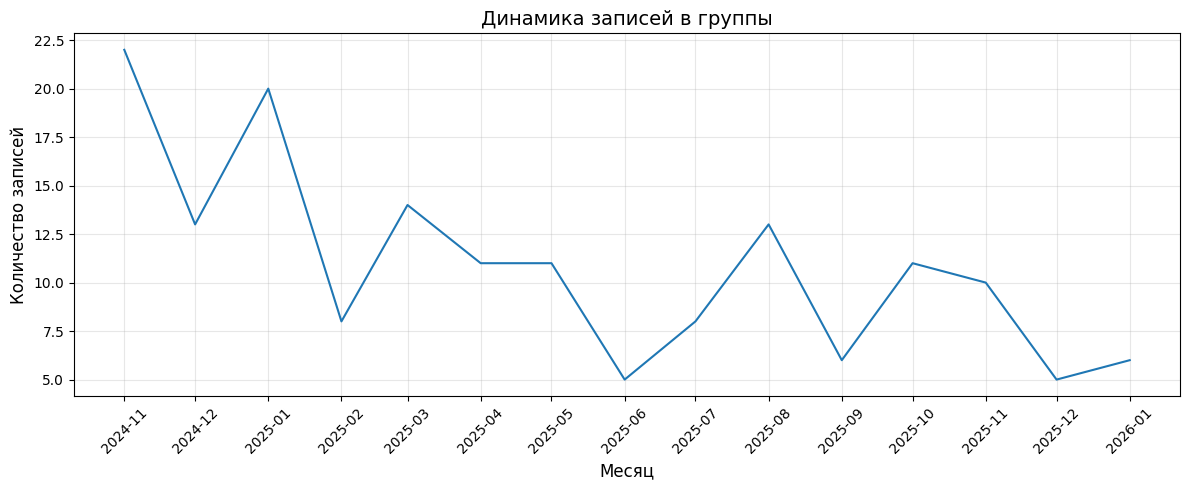

In [54]:
# динамика записей

# дата-время
joins_records['createdAt'] = pd.to_datetime(joins_records['createdAt'], errors='coerce')

# агрегация по месяцам
records_by_month = (
    joins_records
    .dropna(subset=['createdAt'])
    .set_index('createdAt')
    .resample('MS')
    .size()
)

# график
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(records_by_month.index, records_by_month.values)

ax.set_title('Динамика записей в группы', fontsize=14)
ax.set_xlabel('Месяц', fontsize=12)
ax.set_ylabel('Количество записей', fontsize=12)

ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- По записям в группы заметна сезонность с пиками в начале года и просадкой летом
- Во второй половине периода наблюдается общий нисходящий тренд
- Спрос на обучение постепенно снижается

In [55]:
# повторные записи в группы (ретеншн)
joins_records['userId'].value_counts()

userId
6561173    2
6725237    2
6421997    2
7091579    2
7081960    2
          ..
9483628    1
9566041    1
9570969    1
9610712    1
9644079    1
Name: count, Length: 151, dtype: int64

- Повторные записи присутствуют, но их доля невысока, большинство клиентов записываются только один раз
- Retention школы выглядит слабым, бизнес сильно зависит от привлечения новых клиентов

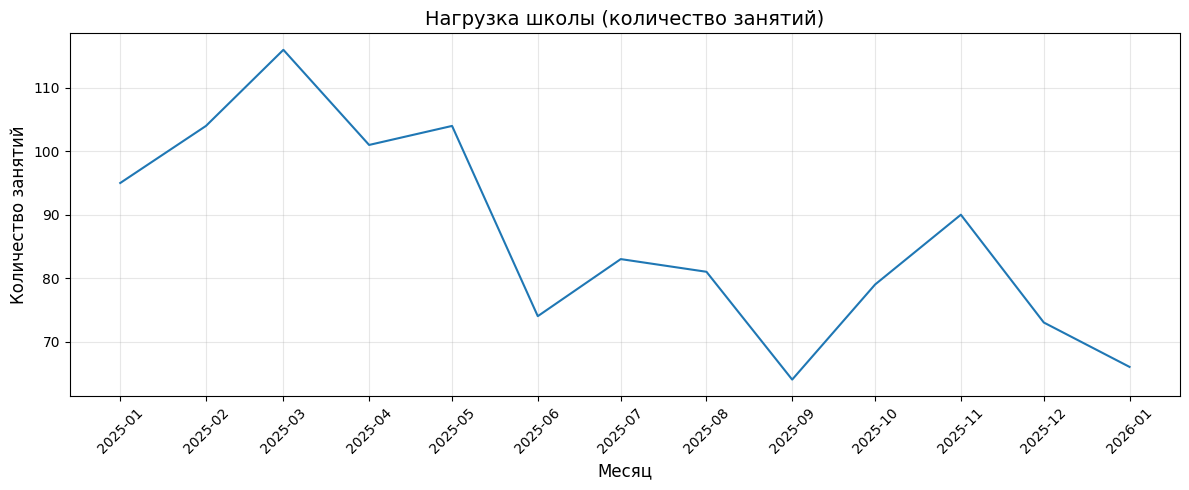

In [56]:
# нагрузка школы

lessons['date'] = pd.to_datetime(lessons['date'], errors='coerce')

lessons_by_month = (
    lessons
    .dropna(subset=['date'])
    .set_index('date')
    .resample('MS')
    .size())

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(lessons_by_month.index, lessons_by_month.values)

ax.set_title('Нагрузка школы (количество занятий)', fontsize=14)
ax.set_xlabel('Месяц', fontsize=12)
ax.set_ylabel('Количество занятий', fontsize=12)

ax.grid(alpha=0.3)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- Нагрузка школы показывает выраженную сезонность с пиком весной и спадом летом
- Во второй половине года уровень занятий остаётся ниже начальных значений
- Общая активность школы снижается

In [57]:
# пиковые дни
lessons['День недели'] = lessons['date'].dt.day_name()
lessons['День недели'].value_counts()

День недели
Wednesday    249
Tuesday      211
Thursday     209
Friday       206
Saturday     140
Monday        63
Sunday        52
Name: count, dtype: int64

In [58]:
# потерянные занятия
joins_records['stats.lessonsLost'].sum()

np.int64(7)

In [59]:
# конверсия из лида в платящего ученика
paid_clients = payments[payments['summa'] > 0]['userId'].nunique()
total_clients = clients['id'].nunique()
conversion_to_payment = paid_clients / total_clients
conversion_to_payment

0.11213872832369942

In [60]:
# повторные покупки (сколько клиентов платят больше 1 раза)
payments_count = payments[payments['summa'] > 0].groupby('userId').size()
(payments_count > 1).mean()

np.float64(0.5670103092783505)

- Пиковая нагрузка приходится на середину недели (вторник–четверг), выходные слабо загружены
- За весь период анализа школа потеряла 7 занятий
- Конверсия в оплату низкая (~11%), среди платящих клиентов повторно оплачивают занятия около половины учеников

## Анализ воронки продаж

### Контакт с компанией (данные Яндекс.Бизнес)

Данные из Яндекс.Бизнес можно считать "контактом" с компанией

In [61]:
yandex_metrics = pd.Series({
    'Просмотры рекламы': ads_views['Просмотры рекламы'].sum(),
    'Переходы по рекламе': clicks['Переходы'].sum(),

    'Карты — переходы на сайт': map_conversions['Переходы на сайт из Карт'].sum(),
    'Карты — клики по телефону': map_conversions['Клики по телефону в Картах'].sum(),
    'Карты — построение маршрута': map_conversions['Построение маршрута в Картах'].sum(),
    'Карты — переход по кнопке': map_conversions['Переход по кнопке действия из Карт'].sum(),
    'Карты — просмотр акции': map_conversions['Просмотр акции в Картах'].sum(),

    'Сайт — переходы в мессенджер': website_conversions['Переход в мессенджер'].sum(),
    'Сайт — заявки': website_conversions['Заявка'].sum(),
    'Сайт — клики по номеру телефона': website_conversions['Клик по номеру телефона'].sum(),
    'Сайт — заполнение контактных данных': website_conversions['Заполнил контактные данные'].sum(),
    'Сайт — отправка формы': website_conversions['Отправка формы_4'].sum(),

    'Профиль — переходы на сайт': profile_conversions['Переходы на сайт'].sum(),
    'Профиль — построение маршрута': profile_conversions['Проложено маршрутов'].sum(),
    'Профиль — нажатия «Позвонить»': profile_conversions['Нажатий «Позвонить»'].sum(),

    'Уникальные входящие номера': call_logs['Номер звонившего'].nunique()
}, name='Количество')

yandex_metrics.to_frame()

,Количество
Просмотры рекламы,368169
Переходы по рекламе,13361
Карты — переходы на сайт,28
Карты — клики по телефону,8
Карты — построение маршрута,7
Карты — переход по кнопке,4
Карты — просмотр акции,1
Сайт — переходы в мессенджер,579
Сайт — заявки,566
Сайт — клики по номеру телефона,133


### Взаимодействие с клиентами (данные CRM)

- Используем данные из CRM для оценки покупки занятий, абонементов, продлений, возвратов и т.д.
- Так как в данных Яндекс.Бизнес нет данных по клиентам, то идентифицировать клиентов в воронке не получится, воронка будет обычная (по суммам событий), а не event funnel

In [62]:
crm_metrics = pd.Series({
    'Клиенты': clients['phone'].dropna().astype(str).nunique(),
    'Типы абонементов': subscriptions['id'].nunique(),
    'Уроки': lessons['id'].nunique(),
    'Платежи': payments['id'].nunique(),
    'Возвраты': (payments['summa'] < 0).sum()
}, name='Количество')

crm_metrics.to_frame()

,Количество
Клиенты,776
Типы абонементов,7
Уроки,1130
Платежи,567
Возвраты,284


Согласно описанию данных, отрицательные суммы в payments - это возвраты. Фактически, все отрицательные суммы в payments - это debit. То есть, видна классическая логика, при которой:
- Клиент пополняет баланс → income (+4800)
- Деньги списываются за абонемент → debit (-4800)

Как следствие, отрицательные суммы принято решение не считать возвратами.

In [63]:
# распределение статусов в таблице уроков
lessons['status'].value_counts()

status
1    1034
0      96
Name: count, dtype: int64

In [64]:
# просмотр строк со статусом 0
status0 = lessons[lessons['status'] == 0]
status0.head()

,id,date,beginTime,endTime,createdAt,filialId,roomId,classId,status,comment,maxStudents,topic,description,teacherIds,День недели
57,53290352,2025-01-18,10:00,11:00,2025-01-11T09:04:33+00:00,55814,86324,536064,0,NaN,0,NaN,NaN,[168728],Saturday
95,53291918,2025-01-21,11:30,12:00,2025-01-11T09:12:25+00:00,55814,86324,536064,0,NaN,0,NaN,NaN,[168728],Tuesday
120,53293476,2025-01-22,10:30,11:30,2025-01-11T09:20:53+00:00,55814,86324,536064,0,NaN,0,NaN,NaN,[168728],Wednesday
164,53739663,2025-01-22,20:00,21:00,2025-01-16T16:23:31+00:00,57619,89604,535053,0,NaN,0,NaN,NaN,[164834],Wednesday
166,53739668,2025-01-22,21:00,22:00,2025-01-16T16:24:03+00:00,57619,89604,535053,0,NaN,0,NaN,NaN,[164834],Wednesday


In [65]:
# просмотр строк со статусом 1
status1 = lessons[lessons['status'] == 1]
status1.head()

,id,date,beginTime,endTime,createdAt,filialId,roomId,classId,status,comment,maxStudents,topic,description,teacherIds,День недели
0,50574598,2025-01-10,12:00,12:50,2024-11-18T10:31:04+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834],Friday
1,50744315,2025-01-09,16:00,16:50,2024-11-21T10:59:31+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834],Thursday
2,50744316,2025-01-16,16:00,16:50,2024-11-21T10:59:31+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834],Thursday
3,52001642,2025-01-10,11:00,12:00,2024-12-14T15:42:36+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834],Friday
4,52001643,2025-01-17,11:00,12:00,2024-12-14T15:42:36+00:00,55814,86324,534888,1,NaN,0,NaN,NaN,[164834],Friday


В описании данных указано, что возможные статусы - запланировано, проведено, отменено. Но при анализе продолжительности уроков с разными статусами не было выявлено закономерностей. При этом, различается classId.

In [66]:
# количество платежей
payments_total = payments['id'].nunique()
payments_total

567

In [67]:
# количество повторных занятий (разница между кол-вом платежей и кол-вом клиентов в базе)
clients_total = clients['phone'].dropna().astype(str).nunique()
repeat_lessons = clients_total - payments_total

repeat_lessons

209

- Из-за отсутствия данных по ученикам нет возможности явно посмотреть конверсию в повторное занятие (нехватка данных)
- Количество абонементов в subscriptions не сходится с количеством уроков в lessons и количеством оплат в payments (нарушена согласованность данных)

In [68]:
crm_data = clients.merge(
    joins_records,
    left_on='id',
    right_on='userId',
    how='left',   # сохраняем всех клиентов, даже если у них не было абонементов
    suffixes=('', '_join')
)

crm_data.head(10)

,id,name,email,phone,advSourceId,balans,bonusBalance,availableBalance,createSourceId,statusChangeReasonId,stateChangedAt,clientStateId,createdAt,updatedAt,filials,responsibles,attributes,joins,tags,id_join,userId,classId,courseId,statusId,stateChangedAt_join,statusChangeReasonId_join,autoJoin,autoDebit,managerId,advSourceId_join,createSourceId_join,tags_join,createdAt_join,updatedAt_join,invoices,stats.visits,stats.freeVisits,stats.nextRecord,stats.lastVisit,stats.lessonsLost,stats.totalPayed,stats.nonPayedLessons,params.nextPay.enabled,params.nextPay.sumType,params.invoices.autoCreate,params.invoices.createRule,params.invoices.joinStateId,params.invoices.payDateDays,params.invoices.payDateType
0,6421631,Гарсия Платон,NaN,NaN,NaN,NaN,0,NaN,1,NaN,2024-11-03T09:46:15+00:00,257526,2024-10-12 19:19:13,2024-11-03T09:46:15+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...",[],"[{'id': 87912, 'name': 'Проверить'}]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6421632,Сафаров Амир,NaN,ph_202754a1b475,NaN,NaN,0,NaN,1,NaN,2024-11-03T09:45:59+00:00,257526,2024-10-12 19:19:13,2024-11-03T09:45:59+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...",[],"[{'id': 87912, 'name': 'Проверить'}]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6421633,Валиев Хакан,NaN,ph_6f516681124a,NaN,NaN,0,NaN,1,NaN,2024-10-18T09:40:33+00:00,257524,2024-10-12 19:19:13,2024-10-18T09:40:33+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...",[],[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6421634,Асланов Амир,NaN,ph_7f3912774b71,NaN,NaN,0,NaN,1,NaN,2024-11-03T09:45:55+00:00,257526,2024-10-12 19:19:13,2024-11-03T09:45:55+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...",[],"[{'id': 87912, 'name': 'Проверить'}]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6421635,Ермолаев Емельян,NaN,ph_7851d3e84643,NaN,NaN,0,NaN,1,NaN,2024-11-03T09:45:47+00:00,257526,2024-10-12 19:19:13,2024-11-03T09:45:47+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...",[],"[{'id': 87912, 'name': 'Проверить'}]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6421636,Асланов Амир,NaN,ph_42242817235a,NaN,0.0,0,0.0,1,NaN,2025-02-14T09:46:28+00:00,257528,2024-10-12 19:19:13,2025-02-14T09:46:28+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...","[{'id': 7384364, 'userId': 6421636, 'classId':...",[],7384364.0,6421636.0,534888.0,0.0,86063.0,2024-11-22T11:44:53+00:00,NaN,True,False,164296.0,NaN,1.0,[],2024-11-22 11:44:53+00:00,2024-12-28T07:16:50+00:00,[],1970-01-01 00:00:00.000000002,0.0,NaN,2024-12-18,0.0,2400.0,0.0,False,full,NaN,NaN,NaN,NaN,NaN
6,6421637,Мансуров Марсель,NaN,ph_dcf09a8bd4c0,NaN,NaN,0,NaN,1,NaN,2024-11-03T09:45:42+00:00,257526,2024-10-12 19:19:13,2024-11-03T09:45:42+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...",[],"[{'id': 87912, 'name': 'Проверить'}]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,6421638,Давлатов Дамир,NaN,ph_61ee61b66414,NaN,NaN,0,NaN,1,529107.0,2024-10-20T15:15:10+00:00,257529,2024-10-12 19:19:13,2024-10-20T15:15:10+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...",[],[],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,6421639,Алтынбаев Артём,NaN,ph_f8098ca2d8c4,NaN,0.0,0,0.0,1,NaN,2024-10-18T09:45:49+00:00,257527,2024-10-12 19:19:13,2025-01-29T16:33:51+00:00,[55814],[],"[{'attributeId': 14, 'attributeAlias': 'subscr...","[{'id': 7404794, 'userId': 6421639, 'classId':...",[],7404794.0,6421639.0,

In [69]:
# сколько строк и сколько уникальных клиентов
print("rows:", len(crm_data))
print("Количество уникальных клиентов:", crm_data['id'].nunique())

# сколько клиентов вообще без абонементов
no_join = crm_data['id_join'].isna().groupby(crm_data['id']).all().sum()
print("Количество клиентов без абонементов:", no_join)

# сколько клиентов с абонементами
with_join = crm_data['id_join'].notna().groupby(crm_data['id']).any().sum()
print("Количество клиентов с абонементами:", with_join)

rows: 877
Количество уникальных клиентов: 865
Количество клиентов без абонементов: 714
Количество клиентов с абонементами: 151


In [70]:
# все клиенты в CRM
total_clients = crm_data['id'].nunique()
total_clients

865

In [71]:
# клиенты, которые купили хотя бы 1 абонемент
buyers = crm_data.loc[crm_data['id_join'].notna(), 'id'].nunique()
buyers

151

In [72]:
# посетили хотя бы 1 урок (есть дата визита)
visited_clients = (
    crm_data
        .assign(last_visit=pd.to_datetime(crm_data['stats.lastVisit'], errors='coerce'))
        .groupby('id')['last_visit']
        .apply(lambda s: s.notna().any())
        .sum()
)

visited_clients

np.int64(132)

In [73]:
# повторные покупки
purchases_per_client = crm_data.groupby('id')['id_join'].count()
purchases_per_client.value_counts().sort_index()

id_join
0    714
1    139
2     12
Name: count, dtype: int64

In [74]:
# среднее количество уроков на клиента
(purchases_per_client > 1).mean()

np.float64(0.013872832369942197)

In [75]:
# конверсия в первую покупку
buyers = (purchases_per_client > 0).sum()
conversion_to_purchase = buyers / purchases_per_client.count()
print("clients → purchase:", round(conversion_to_purchase * 100, 1), "%")

clients → purchase: 17.5 %


In [76]:
# повторные покупки (retention)
repeat_buyers = (purchases_per_client > 1).sum()
print("repeat buyers:", repeat_buyers)
print("share of repeat buyers:", round(repeat_buyers / buyers * 100, 1), "%")

repeat buyers: 12
share of repeat buyers: 7.9 %


### Итоговое описание воронки

**Текущие проблемы в данных:**
- отсутствует таблица лидов
- нет связки "заявка → клиент → платеж → урок"
- отсутствует информация по ученикам (их номера) в записях по урокам/платежам

В силу структуры данных, анализ отражает поведение пользователей на каждом уровне взаимодействия с компанией

**Воронка**
1. Маркетинг:
    - **Переходы по рекламе (13361)**
3. Контакт с компанией (намерение):
    - **Клиенты в CRM (865)** - тут важно проговорить, что это все ученики, не только из рекламы, и включая тех, кто не посетил ни одного урока
    - **Переход в мессенджер (579)**
    - **Заявки (566)** - тут надо понять, что такое заявка (если в месенджере, то конверсия из перехода)
    - Клики по телефону (133)
    - Отправка формы (33)
5. Фактические клиенты (CRM):
    - **Клиенты с абонементами (151)**
    - **Посетили хотя бы один урок (151)**
    - **Повторные покупки (12)**
    - Платежи (567) - тут можно показать долю платежей на клиента
    - Уроки (1130) - тут можно показать долю уроков на клиента/платеж

In [77]:
# сборка итоговой таблицы с метриками

funnel_metrics = {

    # Маркетинг
    "Переходы по рекламе": clicks['Переходы'].sum(),

    # Контакт
    "Клиенты в CRM": clients['id'].nunique(),
    "Переход в мессенджер": website_conversions['Переход в мессенджер'].sum(),
    "Заявки": website_conversions['Заявка'].sum(),

    # Продажи
    "Платежи": payments['id'].nunique(),
    "Клиенты с абонементами": (crm_data.groupby('id')['id_join'].count() > 0).sum(),
    "Посетили хотя бы 1 урок": visited_clients,
    "Повторные покупки": (crm_data.groupby('id')['id_join'].count() > 1).sum()
}

In [78]:
funnel_table = pd.DataFrame(
    funnel_metrics.items(),
    columns=['step', 'value']
)

In [79]:
block_map = {
    "Переходы по рекламе": "Маркетинг",
    
    "Клиенты в CRM": "Контакт",
    "Переход в мессенджер": "Контакт",
    "Заявки": "Контакт",

    "Платежи": "Продажи",
    "Клиенты с абонементами": "Продажи",
    "Посетили хотя бы 1 урок": "Продажи",
    "Повторные покупки": "Продажи"
}

funnel_table['block'] = funnel_table['step'].map(block_map)
funnel_table = funnel_table[['block', 'step', 'value']]
funnel_table.insert(0, 'step_number', range(1, len(funnel_table) + 1))

In [80]:
funnel_table['value'] = pd.to_numeric(funnel_table['value'], errors='coerce')

# % от предыдущего шага
prev = funnel_table['value'].shift(1)
funnel_table['pct_prev'] = np.where(
    prev > 0,
    funnel_table['value'] / prev,
    np.nan
)

# % от первого шага
first = funnel_table['value'].iloc[0]
funnel_table['pct_first'] = np.where(
    first > 0,
    funnel_table['value'] / first,
    np.nan
)

# в процентах
funnel_table['pct_prev'] = (funnel_table['pct_prev'] * 100).round(1)
funnel_table['pct_first'] = (funnel_table['pct_first'] * 100).round(1)

funnel_table.loc[0, 'pct_prev'] = 100

funnel_table

,step_number,block,step,value,pct_prev,pct_first
0,1,Маркетинг,Переходы по рекламе,13361,100.0,100.0
1,2,Контакт,Клиенты в CRM,865,6.5,6.5
2,3,Контакт,Переход в мессенджер,579,66.9,4.3
3,4,Контакт,Заявки,566,97.8,4.2
4,5,Продажи,Платежи,567,100.2,4.2
5,6,Продажи,Клиенты с абонементами,151,26.6,1.1
6,7,Продажи,Посетили хотя бы 1 урок,132,87.4,1.0
7,8,Продажи,Повторные покупки,12,9.1,0.1


In [81]:
# выгрузка итоговой таблицы для визуализации в Tableau
funnel_table.to_csv(
    r"./data/soultune/funnel.csv",
    index=False
)

In [82]:
# сборка итоговой таблицы с метриками

funnel_metrics_small = {
    # Контакт
    "1. Клиенты в CRM": clients['id'].nunique(),
    "2. Переход в мессенджер": website_conversions['Переход в мессенджер'].sum(),
    "3. Заявки": website_conversions['Заявка'].sum(),

    # Продажи
    "4. Платежи": payments['id'].nunique(),
    "5. Клиенты с абонементами": (crm_data.groupby('id')['id_join'].count() > 0).sum(),
    "6. Посетили хотя бы 1 урок": visited_clients,
    "7. Повторные покупки": (crm_data.groupby('id')['id_join'].count() > 1).sum()
}

In [83]:
funnel_table_small = pd.DataFrame(
    funnel_metrics_small.items(),
    columns=['step', 'value']
)

In [84]:
block_map_small = {    
    "1. Клиенты в CRM": "Контакт",
    "2. Переход в мессенджер": "Контакт",
    "3. Заявки": "Контакт",

    "4. Платежи": "Продажи",
    "5. Клиенты с абонементами": "Продажи",
    "6. Посетили хотя бы 1 урок": "Продажи",
    "7. Повторные покупки": "Продажи"
}

funnel_table_small['block'] = funnel_table_small['step'].map(block_map_small)
funnel_table_small = funnel_table_small[['block', 'step', 'value']]
funnel_table_small.insert(0, 'step_number', range(1, len(funnel_table_small) + 1))

In [85]:
funnel_table_small['value'] = pd.to_numeric(funnel_table_small['value'], errors='coerce')

# % от предыдущего шага
prev = funnel_table_small['value'].shift(1)
funnel_table_small['pct_prev'] = np.where(
    prev > 0,
    funnel_table_small['value'] / prev,
    np.nan
)

# % от первого шага
first = funnel_table_small['value'].iloc[0]
funnel_table_small['pct_first'] = np.where(
    first > 0,
    funnel_table_small['value'] / first,
    np.nan
)

# в процентах
funnel_table_small['pct_prev'] = (funnel_table_small['pct_prev'] * 100).round(1)
funnel_table_small['pct_first'] = (funnel_table_small['pct_first'] * 100).round(1)

funnel_table_small.loc[0, 'pct_prev'] = 100

funnel_table_small

,step_number,block,step,value,pct_prev,pct_first
0,1,Контакт,1. Клиенты в CRM,865,100.0,100.0
1,2,Контакт,2. Переход в мессенджер,579,66.9,66.9
2,3,Контакт,3. Заявки,566,97.8,65.4
3,4,Продажи,4. Платежи,567,100.2,65.5
4,5,Продажи,5. Клиенты с абонементами,151,26.6,17.5
5,6,Продажи,6. Посетили хотя бы 1 урок,132,87.4,15.3
6,7,Продажи,7. Повторные покупки,12,9.1,1.4


In [86]:
# выгрузка итоговой таблицы для визуализации в Tableau
funnel_table_small.to_csv(
    r"./data/soultune/funnel_small.csv",
    index=False
)